# Movie Industry Analysis
**Dataset:** 7,668 movies (1980–2020) from IMDb  
**Tools:** Python (pandas, matplotlib, seaborn)  

## Project Goal
This project analyzes the movie industry to answer one key question:

> **What drives box office success — budget, ratings, genre, or star power?**

We explore gross revenue across genres, directors, stars, production companies, and years.

In [1]:
import pandas as pd
df = pd.read_csv('/Users/siheng/Documents/workspace/movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Section 1: Dataset Overview

The dataset contains 7,668 movies from 1980 to 2020 with 15 columns including budget, gross revenue, IMDb score, genre, director, and star.

In [2]:
df.columns.tolist()

['name',
 'rating',
 'genre',
 'year',
 'released',
 'score',
 'votes',
 'director',
 'writer',
 'star',
 'country',
 'budget',
 'gross',
 'company',
 'runtime']

In [3]:
df.shape

(7668, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   str    
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 898.7 KB


## Section 2: Data Cleaning

Not all movies have budget or gross revenue data. We create two cleaned versions:
- : movies with gross revenue data (used for most analyses)
- : movies with both budget and gross (used for ROI and budget analyses)

In [5]:
df_gross = df.dropna(subset=['gross'])
df_clean = df.dropna(subset=['budget', 'gross'])

print(f"Original dataset: {df.shape[0]} rows")
print(f"With gross data: {df_gross.shape[0]} rows")
print(f"With budget + gross data: {df_clean.shape[0]} rows")


Original dataset: 7668 rows
With gross data: 7479 rows
With budget + gross data: 5436 rows


In [6]:
df_clean = df_clean.copy()
df_clean['ROI'] = df_clean['gross'] / df_clean['budget']
df_clean.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,ROI
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,2.473620
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,13.078468
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,29.909726
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,23.843868
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,6.641057


## Section 3: Key Findings

### Finding 1: Animation and Family Films Generate the Highest Average Revenue

We group movies by genre and calculate the average gross revenue to compare earning potential across genres.

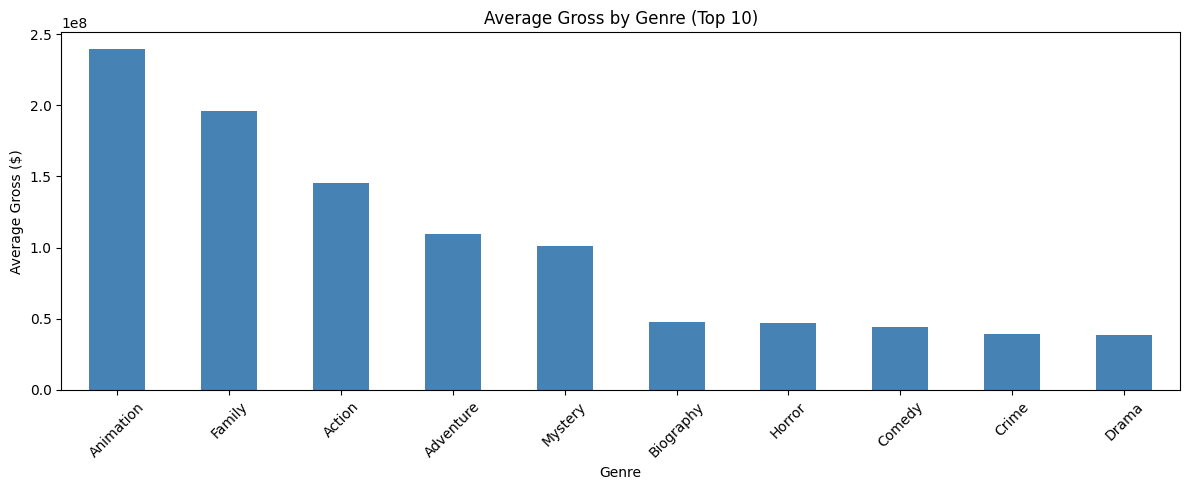

In [7]:
import matplotlib.pyplot as plt

genre_gross = df_gross.groupby('genre')['gross'].mean().sort_values(ascending=False).head(10)
genre_gross.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Average Gross by Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Average Gross ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Animation leads with ~M average gross, followed by Family (~M). These genres appeal to all age groups, giving them the widest audience.

### Finding 2: Family and Thriller Films Deliver the Best ROI

High gross revenue does not always mean high return. We use median ROI (gross / budget) to measure efficiency.

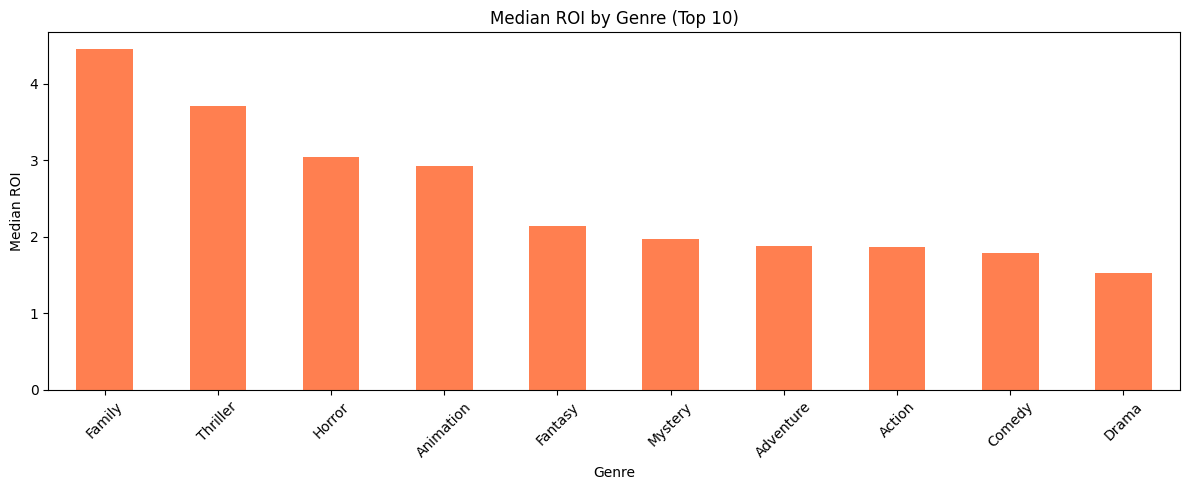

In [8]:
genre_roi = df_clean.groupby('genre')['ROI'].median().sort_values(ascending=False).head(10)
genre_roi.plot(kind='bar', figsize=(12, 5), color='coral')
plt.title('Median ROI by Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Median ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Family films have a median ROI of 4.5x, meaning for every  invested, the film earns .50 back. Animation has high gross but lower ROI due to expensive production costs. Median is used here instead of mean to avoid distortion from outliers.

### Finding 3: Budget and Gross Revenue Are Positively Correlated — But Not Guaranteed

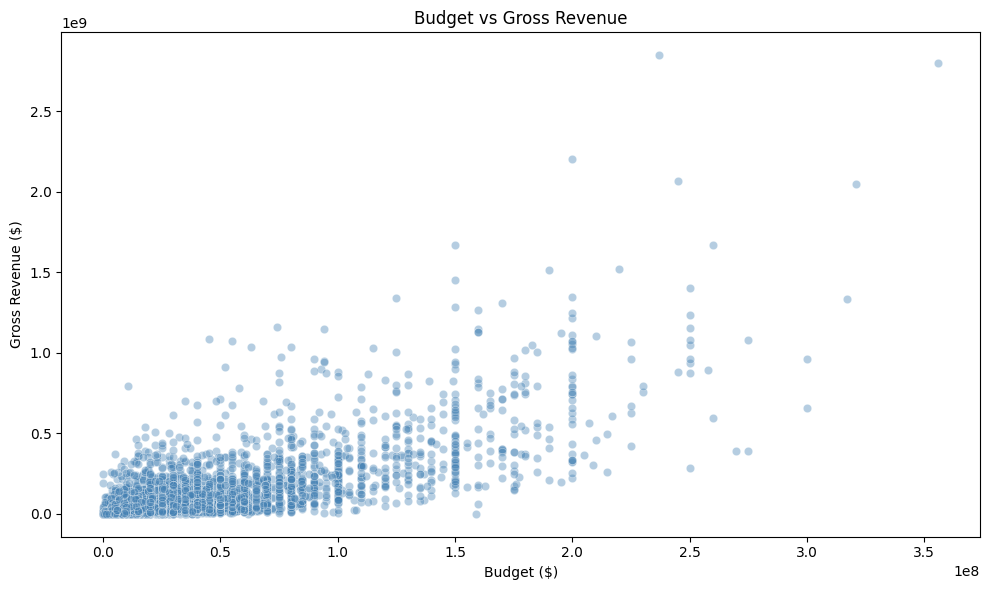

In [9]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='budget', y='gross', alpha=0.4, color='steelblue')
plt.title('Budget vs Gross Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.tight_layout()
plt.show()


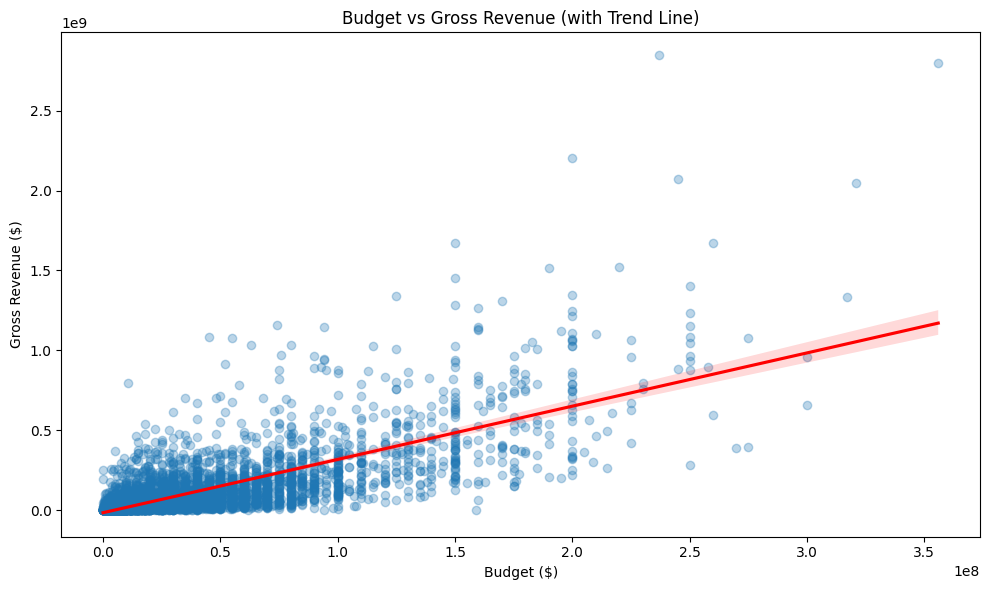

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='budget', y='gross', 
            scatter_kws={'alpha': 0.3}, 
            line_kws={'color': 'red'})
plt.title('Budget vs Gross Revenue (with Trend Line)')
plt.xlabel('Budget ($)')
plt.ylabel('Gross Revenue ($)')
plt.tight_layout()
plt.show()


**Insight:** There is a positive correlation between budget and gross revenue — higher budgets generally lead to higher returns. However, the wide spread of points shows that big budgets do not guarantee success. Some high-budget films fail while some low-budget films outperform expectations.

### Finding 4: IMDb Score Has a Weak Positive Correlation with Gross Revenue

We filter movies with at least 10,000 votes to ensure ratings are statistically meaningful.

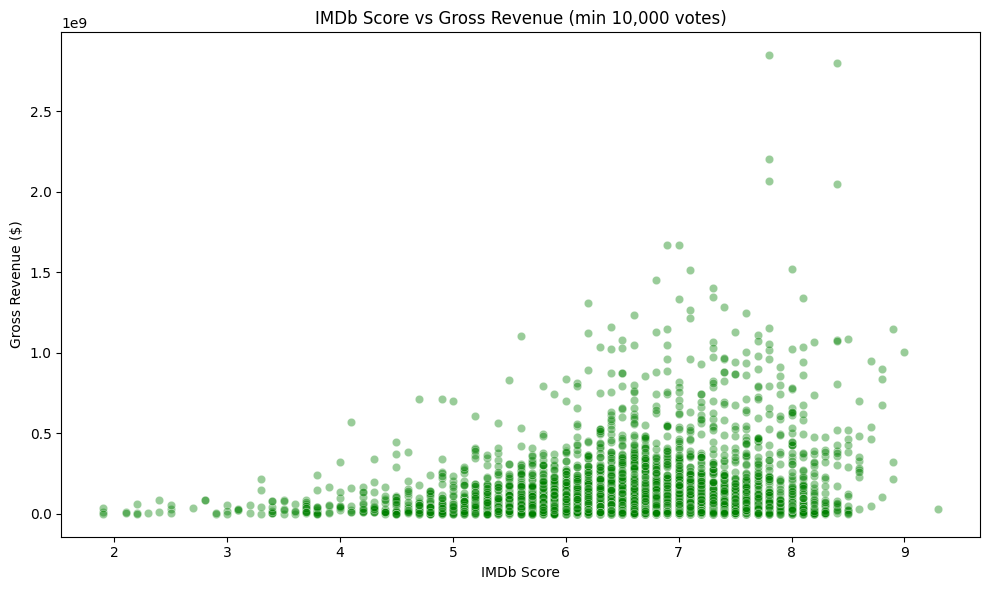

In [11]:
df_score = df_gross[df_gross['votes'] >= 10000]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_score, x='score', y='gross', alpha=0.4, color='green')
plt.title('IMDb Score vs Gross Revenue (min 10,000 votes)')
plt.xlabel('IMDb Score')
plt.ylabel('Gross Revenue ($)')
plt.tight_layout()
plt.show()


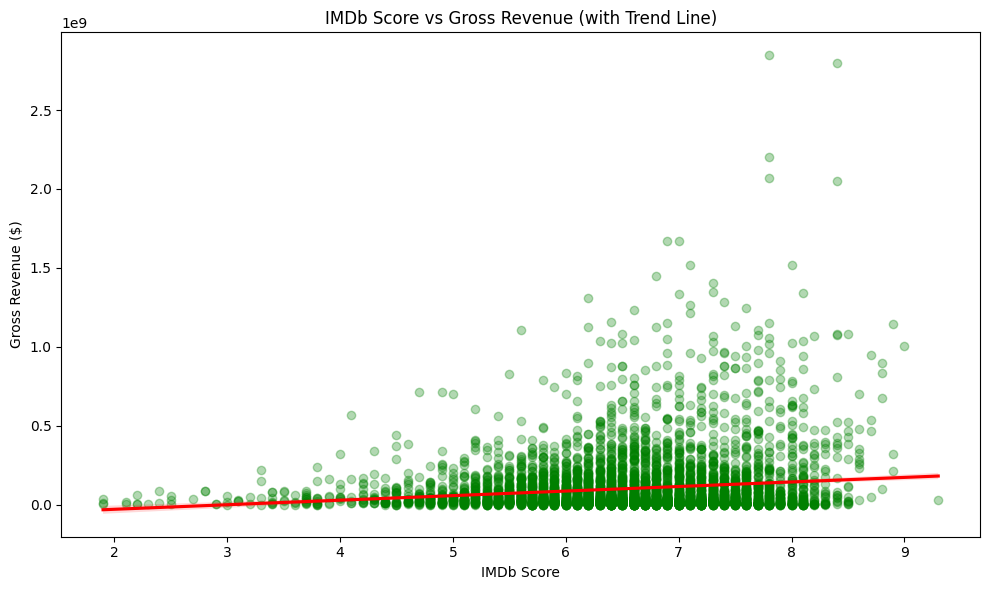

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_score, x='score', y='gross',
            scatter_kws={'alpha': 0.3, 'color': 'green'},
            line_kws={'color': 'red'})
plt.title('IMDb Score vs Gross Revenue (with Trend Line)')
plt.xlabel('IMDb Score')
plt.ylabel('Gross Revenue ($)')
plt.tight_layout()
plt.show()


**Insight:** Higher-rated films tend to earn slightly more, but the relationship is weak. Many mid-rated films earn just as much as highly-rated ones. Audiences buy tickets based on marketing, franchise loyalty, and star power — not just critical reception.

### Finding 5: Steven Spielberg is the Highest-Grossing Director of All Time

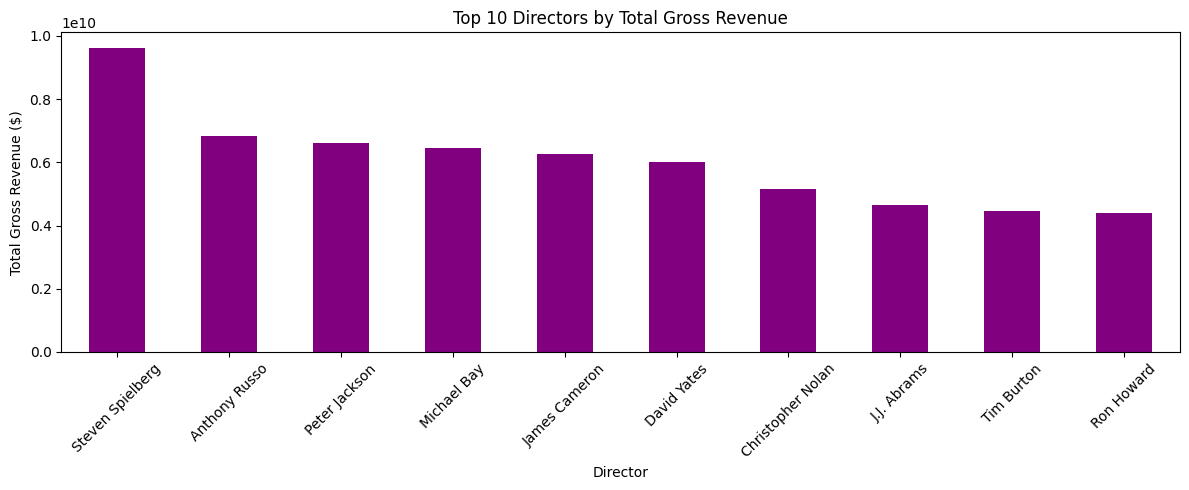

In [13]:
director_gross = df_gross.groupby('director')['gross'].sum().sort_values(ascending=False).head(10)
director_gross.plot(kind='bar', figsize=(12, 5), color='purple')
plt.title('Top 10 Directors by Total Gross Revenue')
plt.xlabel('Director')
plt.ylabel('Total Gross Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Spielberg leads with nearly B in total gross across decades of blockbusters (Jurassic Park, Schindler's List, Indiana Jones). Anthony Russo follows with the Avengers franchise. James Cameron ranks 5th despite directing only a handful of films — each one a record-breaker.

### Finding 6: Robert Downey Jr. is the Highest-Grossing Actor

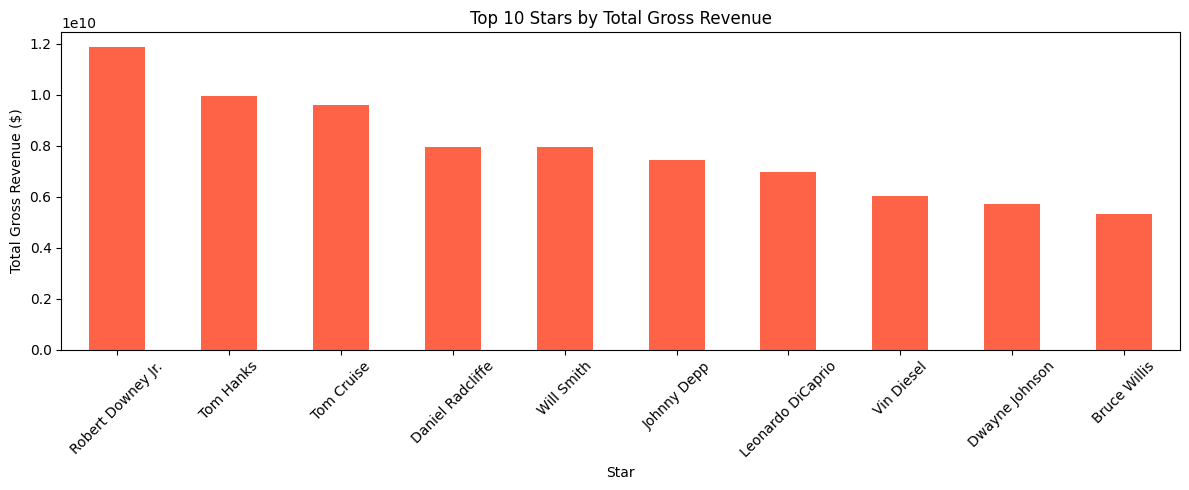

In [14]:
star_gross = df_gross.groupby('star')['gross'].sum().sort_values(ascending=False).head(10)
star_gross.plot(kind='bar', figsize=(12, 5), color='tomato')
plt.title('Top 10 Stars by Total Gross Revenue')
plt.xlabel('Star')
plt.ylabel('Total Gross Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Robert Downey Jr. (Iron Man) leads with B, driven almost entirely by the Marvel Cinematic Universe. Tom Hanks and Tom Cruise follow with consistent multi-decade careers. Daniel Radcliffe's ranking comes entirely from the Harry Potter franchise.

### Finding 7: Average Box Office Revenue Has Grown Steadily Since 1990

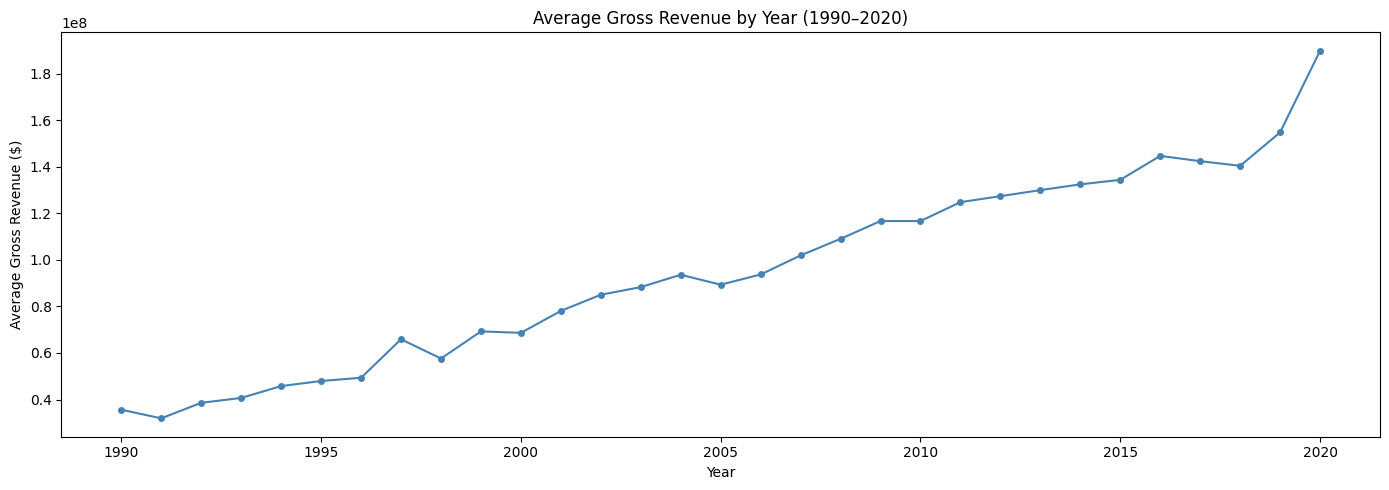

In [15]:
year_gross = df_gross[df_gross['year'] >= 1990].groupby('year')['gross'].mean()
year_gross.plot(kind='line', figsize=(14, 5), color='steelblue', marker='o', markersize=4)
plt.title('Average Gross Revenue by Year (1990–2020)')
plt.xlabel('Year')
plt.ylabel('Average Gross Revenue ($)')
plt.tight_layout()
plt.show()


**Insight:** Average gross revenue grew from ~M in 1990 to ~M in 2019 — a 5x increase over 30 years. The growth reflects rising ticket prices, global market expansion, and the dominance of franchise films. Note: 2020 data appears high due to low sample size (most films were delayed due to COVID-19).

### Finding 8: Marvel Studios Leads All Production Companies in Average Gross Revenue

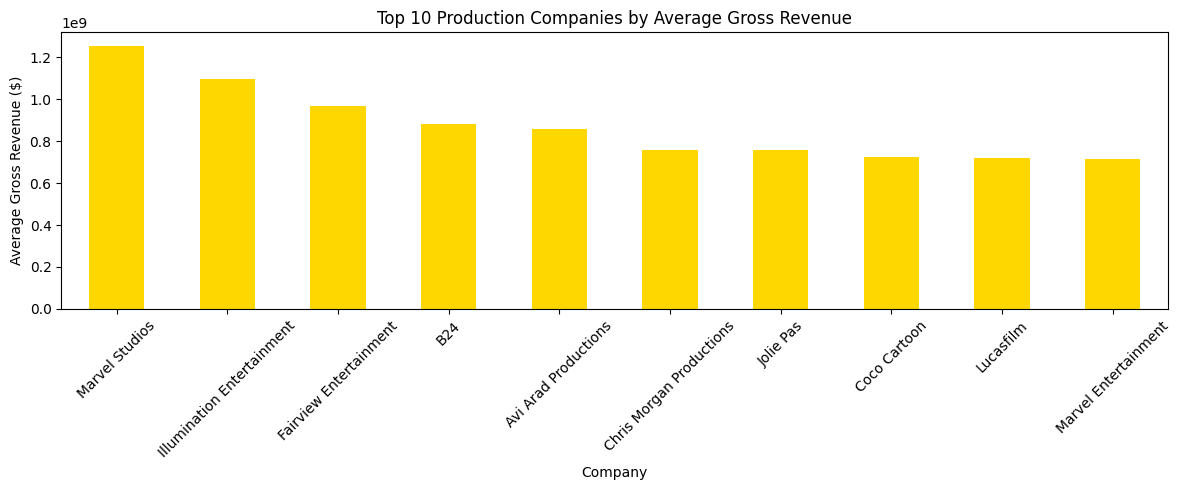

In [16]:
company_gross = df_gross.groupby('company')['gross'].mean().sort_values(ascending=False).head(10)
company_gross.plot(kind='bar', figsize=(12, 5), color='gold')
plt.title('Top 10 Production Companies by Average Gross Revenue')
plt.xlabel('Company')
plt.ylabel('Average Gross Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Marvel Studios leads with ~.25B average gross per film, followed by Illumination Entertainment (~.1B, makers of Minions and Despicable Me). Both specialize in franchise films with built-in audiences. Lucasfilm (Star Wars) also appears, reflecting the value of established IP.

---

## Section 4: Business Recommendations

### 1. Invest in Animation and Family Franchises
These genres consistently deliver the highest average gross revenue and strong ROI. Studios should prioritize building franchise IP in these categories rather than one-off productions.

### 2. Set Budget Guardrails — Big Budgets Do Not Guarantee Returns
While budget and gross are positively correlated, the variance is enormous. Studios should implement ROI benchmarks before greenlighting high-budget productions, especially outside the Animation and Action genres.

### 3. Prioritize Star Power and Franchise Casting Over Critical Ratings
IMDb score shows only a weak correlation with box office performance. Casting bankable stars (top 10 actors by gross) and developing sequels within proven franchises is a more reliable revenue strategy than chasing critical acclaim.

In [ ]:
import sqlite3
import pandas as pd

# Load data for SQL analysis
_df = pd.read_csv("/Users/siheng/Documents/workspace/movies.csv")
_df_sql = _df.dropna(subset=["gross"])

conn = sqlite3.connect(":memory:")
_df_sql.to_sql("movies", conn, index=False, if_exists="replace")
print("SQL database ready! Rows:", len(_df_sql))